# Unseen Device Evaluation in Relative Space

This notebook runs fresh inference on unseen ECE sensor datasets using the saved full model package.

The model output is in the learned training space, while the unseen device target is a relative moisture percentage signal. Because of that, evaluation is done in relative space so the comparison is aligned.

This is a trend tracking check, not a conversion back to physical VWC.


## Setup and Imports

This section loads paths, imports, and the bundled full model object.


In [1]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


In [2]:
# Data

DEV3_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d3/final_d3.csv'
DEV4_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d4/final_d4.csv'
DEV7_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d7/final_d7.csv'

BEST_MODEL_PATH = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/best_model.pkl'
PREDS = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/test_predictions_weighted.csv'
TRAINVAL_W = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/trainval_weights.pkl'
FULL_MODEL = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/xgb_drift_weighted_full.pkl'

obj = joblib.load(FULL_MODEL)

model = obj["model"]
features = obj["features"]

print(f'Model loaded from FULL_MODEL: {FULL_MODEL}')
print(f'Feature count: {len(features)}')


Model loaded from FULL_MODEL: /Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/xgb_drift_weighted_full.pkl
Feature count: 38


## Load Unseen Device Datasets

Read each device file, parse date columns if present, and inspect basic structure.


In [3]:
device_paths = {
    'd3': DEV3_PATH,
    'd4': DEV4_PATH,
    'd7': DEV7_PATH,
}

def parse_date_columns(df: pd.DataFrame) -> list:
    parsed_cols = []
    date_candidates = [
        c for c in df.columns
        if c.lower() in {'date', 'datetime', 'timestamp', 'time'} or 'date' in c.lower() or 'time' in c.lower()
    ]
    for col in date_candidates:
        parsed = pd.to_datetime(df[col], errors='coerce')
        if parsed.notna().mean() >= 0.8:
            df[col] = parsed
            parsed_cols.append(col)
    return parsed_cols

device_dfs = {}
load_rows = []

for dev, path in device_paths.items():
    df = pd.read_csv(path)
    parsed_cols = parse_date_columns(df)
    device_dfs[dev] = df
    key_cols = [c for c in ['station_id', 'date', 'datetime', 'timestamp', 'MoistureDailyAvg (%)', 'soil_moisture_5cm'] if c in df.columns]
    load_rows.append({
        'device': dev,
        'rows': len(df),
        'cols': len(df.columns),
        'parsed_date_cols': ', '.join(parsed_cols) if parsed_cols else 'none',
        'key_cols_present': ', '.join(key_cols) if key_cols else 'none',
    })

load_summary = pd.DataFrame(load_rows)
display(load_summary)


,device,rows,cols,parsed_date_cols,key_cols_present
0,d3,11,499,date,"station_id, date, soil_moisture_5cm"
1,d4,11,499,date,"station_id, date, soil_moisture_5cm"
2,d7,13,499,date,"station_id, date, soil_moisture_5cm"


## Schema and Feature Checks

Each device must contain every required feature from `FULL_MODEL`. Extra columns are allowed.


In [4]:
schema_rows = []
missing_by_device = {}

for dev, df in device_dfs.items():
    missing = [f for f in features if f not in df.columns]
    missing_by_device[dev] = missing
    schema_rows.append({
        'device': dev,
        'required_features': len(features),
        'missing_required_features': len(missing),
    })

schema_summary = pd.DataFrame(schema_rows)
display(schema_summary)

has_missing = any(len(v) > 0 for v in missing_by_device.values())
if has_missing:
    missing_report = {k: v for k, v in missing_by_device.items() if v}
    raise ValueError(
        'Missing required model features detected. '        f'Per-device missing features: {missing_report}. '        'Stop here and fix schema alignment before inference.'
    )

print('All required model features are present for d3, d4, and d7.')


,device,required_features,missing_required_features
0,d3,38,0
1,d4,38,0
2,d7,38,0


All required model features are present for d3, d4, and d7.


## Fresh Predictions From FULL_MODEL

Run inference directly from `model.predict(df[features])` for each unseen device file.


In [5]:
for dev, df in device_dfs.items():
    df['pred_vwc'] = model.predict(df[features])

pred_summary = pd.DataFrame([
    {
        'device': dev,
        'pred_vwc_min': float(df['pred_vwc'].min()),
        'pred_vwc_max': float(df['pred_vwc'].max()),
        'pred_vwc_mean': float(df['pred_vwc'].mean()),
    }
    for dev, df in device_dfs.items()
])

display(pred_summary)


,device,pred_vwc_min,pred_vwc_max,pred_vwc_mean
0,d3,0.127259,0.247133,0.182075
1,d4,0.116147,0.245404,0.186017
2,d7,0.116167,0.262963,0.194750


## Target Preparation in Relative Space

We look for the ECE relative percentage target, expected as `MoistureDailyAvg (%)` or a close variant.

The selected percent target is converted to `[0, 1]` as `target_rel = percent / 100`.


In [7]:
TARGET_CANDIDATES = [
    'MoistureDailyAvg (%)',
    'soil_moisture_5cm'
]

def pick_target_column(df: pd.DataFrame) -> str:
    for col in TARGET_CANDIDATES:
        if col in df.columns:
            return col

    lower_map = {c.lower().strip(): c for c in df.columns}
    for col in TARGET_CANDIDATES:
        candidate = lower_map.get(col.lower().strip())
        if candidate is not None:
            return candidate

    fuzzy = [
        c for c in df.columns
        if ('moisture' in c.lower() and '%' in c) or ('moisturedailyavg' in c.lower())
    ]
    if len(fuzzy) == 1:
        return fuzzy[0]

    raise ValueError(
        'Could not uniquely find an ECE relative moisture target column. '        f'Looked for: {TARGET_CANDIDATES}. '        f'Fuzzy matches found: {fuzzy}'
    )

target_columns = {}
for dev, df in device_dfs.items():
    target_col = pick_target_column(df)
    target_columns[dev] = target_col
    target_raw = pd.to_numeric(df[target_col], errors='coerce')
    df['target_rel'] = target_raw / 100.0
    df.loc[~np.isfinite(df['target_rel']), 'target_rel'] = np.nan
    df.loc[(df['target_rel'] < 0) | (df['target_rel'] > 1), 'target_rel'] = np.nan

print('Detected target columns by device:')
print(target_columns)

target_summary = pd.DataFrame([
    {
        'device': dev,
        'target_col': target_columns[dev],
        'valid_target_rel_rows': int(df['target_rel'].notna().sum()),
        'target_rel_min': float(df['target_rel'].min(skipna=True)) if df['target_rel'].notna().any() else np.nan,
        'target_rel_max': float(df['target_rel'].max(skipna=True)) if df['target_rel'].notna().any() else np.nan,
    }
    for dev, df in device_dfs.items()
])

display(target_summary)


Detected target columns by device:
{'d3': 'soil_moisture_5cm', 'd4': 'soil_moisture_5cm', 'd7': 'soil_moisture_5cm'}


,device,target_col,valid_target_rel_rows,target_rel_min,target_rel_max
0,d3,soil_moisture_5cm,7,0.002345,0.697457
1,d4,soil_moisture_5cm,8,0.088321,0.282801
2,d7,soil_moisture_5cm,11,0.763814,0.850765


## Relative Prediction Transform

`pred_vwc` is not treated as directly equal to percentage. For comparison only, we scale predictions per device with min max normalization:

`pred_rel = (pred_vwc - min(pred_vwc)) / (max(pred_vwc) - min(pred_vwc))`

This creates a relative trend scale per device. It does not convert predictions into physical truth.


In [8]:
for dev, df in device_dfs.items():
    pmin = df['pred_vwc'].min()
    pmax = df['pred_vwc'].max()
    if not np.isfinite(pmin) or not np.isfinite(pmax) or pmax <= pmin:
        df['pred_rel'] = np.nan
    else:
        df['pred_rel'] = (df['pred_vwc'] - pmin) / (pmax - pmin)

rel_pred_summary = pd.DataFrame([
    {
        'device': dev,
        'pred_rel_valid_rows': int(df['pred_rel'].notna().sum()),
        'pred_rel_min': float(df['pred_rel'].min(skipna=True)) if df['pred_rel'].notna().any() else np.nan,
        'pred_rel_max': float(df['pred_rel'].max(skipna=True)) if df['pred_rel'].notna().any() else np.nan,
    }
    for dev, df in device_dfs.items()
])

display(rel_pred_summary)


,device,pred_rel_valid_rows,pred_rel_min,pred_rel_max
0,d3,11,0.0,1.0
1,d4,11,0.0,1.0
2,d7,13,0.0,1.0


## Per Device Metrics in Relative Space

Primary metrics for this notebook are Spearman and Pearson because this is a relative trend tracking evaluation.

RMSE and MAE provide secondary error context in relative space.

R2 is diagnostic only and is explicitly flagged as unstable when target variation is limited or when R2 is highly negative.


In [9]:
def compute_device_metrics(df: pd.DataFrame, device: str) -> dict:
    eval_df = df[['target_rel', 'pred_rel']].dropna().copy()
    n = len(eval_df)
    target_range = eval_df['target_rel'].max() - eval_df['target_rel'].min() if n else np.nan

    if n < 3:
        return {
            'device': device,
            'n_eval': n,
            'target_rel_range': target_range,
            'pearson': np.nan,
            'spearman': np.nan,
            'rmse_rel': np.nan,
            'mae_rel': np.nan,
            'r2_rel': np.nan,
            'r2_flag': 'insufficient rows',
        }

    y = eval_df['target_rel'].to_numpy()
    yhat = eval_df['pred_rel'].to_numpy()

    err = yhat - y
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))

    pearson = float(eval_df['target_rel'].corr(eval_df['pred_rel'], method='pearson'))
    spearman = float(eval_df['target_rel'].corr(eval_df['pred_rel'], method='spearman'))

    y_mean = float(np.mean(y))
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y_mean) ** 2))
    r2 = np.nan if ss_tot <= 1e-12 else float(1 - (ss_res / ss_tot))

    r2_warnings = []
    if np.isfinite(target_range) and target_range < 0.15:
        r2_warnings.append('narrow target range')
    if np.isfinite(r2) and r2 < -1:
        r2_warnings.append('unstable R2')

    if r2_warnings:
        r2_flag = ' + '.join(r2_warnings)
    else:
        r2_flag = 'no trigger'

    return {
        'device': device,
        'n_eval': n,
        'target_rel_range': float(target_range),
        'pearson': pearson,
        'spearman': spearman,
        'rmse_rel': rmse,
        'mae_rel': mae,
        'r2_rel': r2,
        'r2_flag': r2_flag,
    }

metrics_df = pd.DataFrame([
    compute_device_metrics(df, dev)
    for dev, df in device_dfs.items()
]).sort_values('device').reset_index(drop=True)

def r2_use_note(row: pd.Series) -> str:
    if row['device'] in {'d4', 'd7'}:
        return 'not suitable for meaningful R2 interpretation'
    if row['r2_flag'] != 'no trigger':
        return 'R2 is unstable for this device'
    return 'R2 is secondary; prioritize correlation'

metrics_df['r2_use_note'] = metrics_df.apply(r2_use_note, axis=1)

display(metrics_df)


,device,n_eval,target_rel_range,pearson,spearman,rmse_rel,mae_rel,r2_rel,r2_flag,r2_use_note
0,d3,7,0.695112,0.811899,0.821429,0.277364,0.233723,-0.342047,no trigger,R2 is secondary; prioritize correlation
1,d4,8,0.194480,0.652658,0.547619,0.513969,0.380732,-74.574138,unstable R2,not suitable for meaningful R2 interpretation
2,d7,11,0.086951,0.244541,0.227273,0.387045,0.265723,-295.304407,narrow target range + unstable R2,not suitable for meaningful R2 interpretation


## Quick Interpretation

Spearman and Pearson are the main readout for whether the model follows relative moisture dynamics.

R2 is a secondary diagnostic and should not drive conclusions in this setup.

For this notebook, d4 and d7 should be treated as not suitable for meaningful R2 interpretation.


In [10]:
for _, row in metrics_df.iterrows():
    dev = row['device']
    pr = row['pearson']
    sr = row['spearman']
    r2 = row['r2_rel']
    r2_flag = row['r2_flag']
    r2_note = row['r2_use_note']

    print(f"{dev}: spearman={sr:.3f}, pearson={pr:.3f}, rmse_rel={row['rmse_rel']:.3f}, mae_rel={row['mae_rel']:.3f}")
    print(f"    r2_rel={r2:.3f} | flag={r2_flag} | note={r2_note}")


d3: spearman=0.821, pearson=0.812, rmse_rel=0.277, mae_rel=0.234
    r2_rel=-0.342 | flag=no trigger | note=R2 is secondary; prioritize correlation
d4: spearman=0.548, pearson=0.653, rmse_rel=0.514, mae_rel=0.381
    r2_rel=-74.574 | flag=unstable R2 | note=not suitable for meaningful R2 interpretation
d7: spearman=0.227, pearson=0.245, rmse_rel=0.387, mae_rel=0.266
    r2_rel=-295.304 | flag=narrow target range + unstable R2 | note=not suitable for meaningful R2 interpretation


## Plots Per Device

For each device:
- time series of target_rel vs pred_rel
- scatter of target_rel vs pred_rel
- residual plot of pred_rel - target_rel versus target_rel

Plots use matplotlib only and each figure is a single chart.


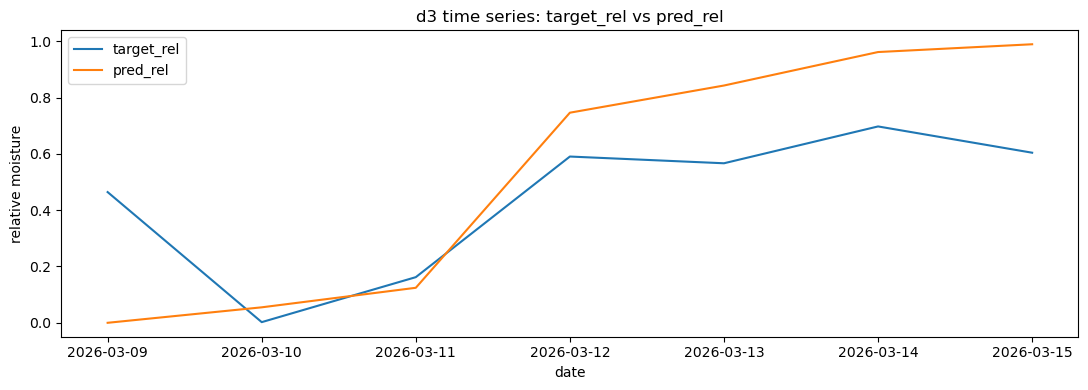

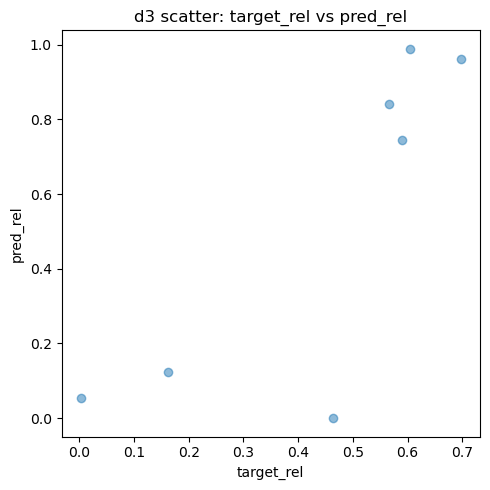

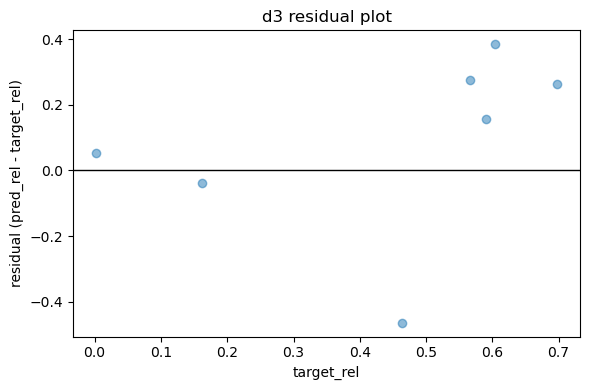

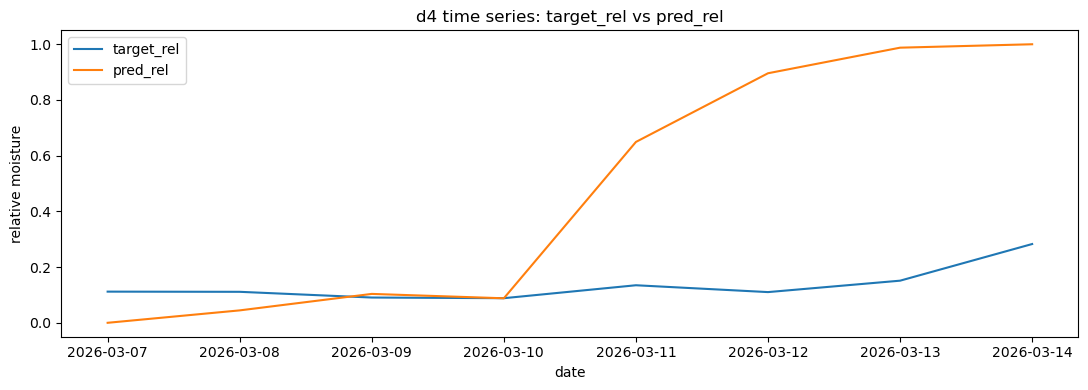

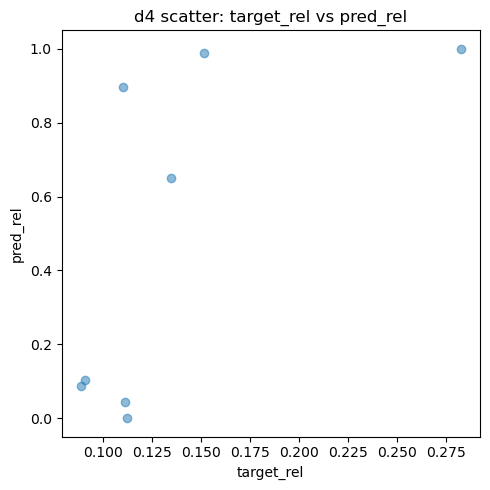

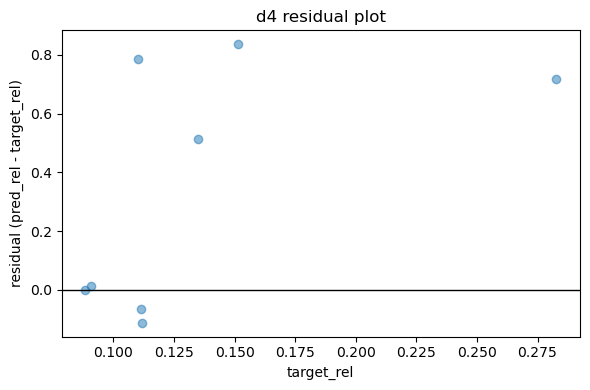

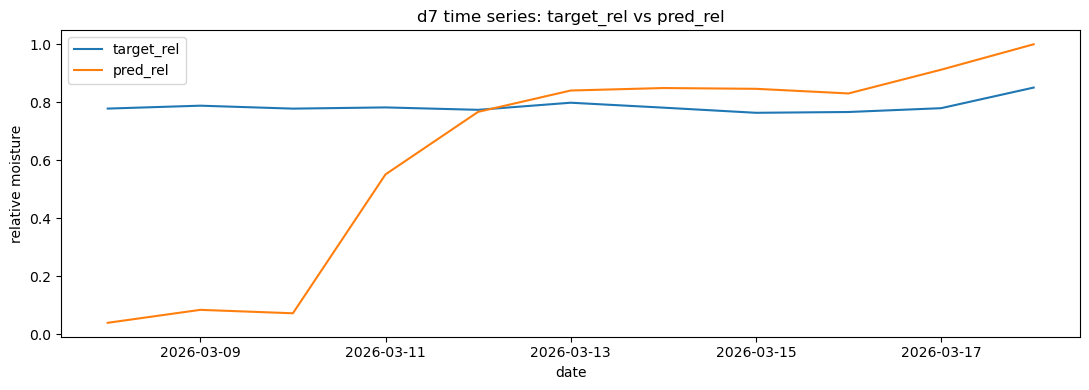

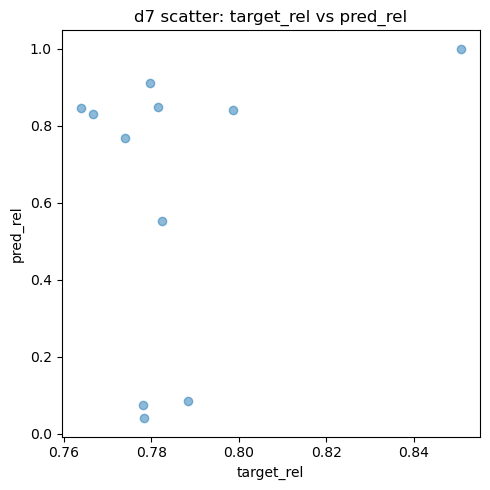

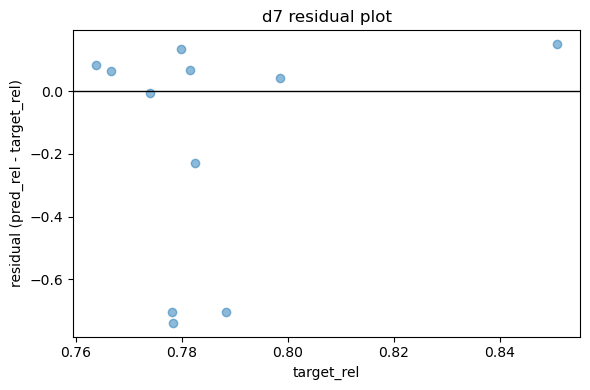

In [11]:
def pick_date_col(df: pd.DataFrame):
    for col in ['date', 'datetime', 'timestamp', 'time']:
        if col in df.columns:
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                return col
            converted = pd.to_datetime(df[col], errors='coerce')
            if converted.notna().mean() >= 0.8:
                df[col] = converted
                return col
    return None

for dev, df in device_dfs.items():
    eval_df = df[['target_rel', 'pred_rel']].copy().dropna()
    date_col = pick_date_col(df)

    if date_col is not None:
        ts_df = df[[date_col, 'target_rel', 'pred_rel']].dropna().sort_values(date_col)
    else:
        ts_df = eval_df.reset_index().rename(columns={'index': 'row_id'})

    plt.figure(figsize=(11, 4))
    if date_col is not None:
        plt.plot(ts_df[date_col], ts_df['target_rel'], label='target_rel', linewidth=1.5)
        plt.plot(ts_df[date_col], ts_df['pred_rel'], label='pred_rel', linewidth=1.5)
        plt.xlabel(date_col)
    else:
        plt.plot(ts_df['row_id'], ts_df['target_rel'], label='target_rel', linewidth=1.5)
        plt.plot(ts_df['row_id'], ts_df['pred_rel'], label='pred_rel', linewidth=1.5)
        plt.xlabel('row index')
    plt.ylabel('relative moisture')
    plt.title(f'{dev} time series: target_rel vs pred_rel')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 5))
    plt.scatter(eval_df['target_rel'], eval_df['pred_rel'], alpha=0.5)
    plt.xlabel('target_rel')
    plt.ylabel('pred_rel')
    plt.title(f'{dev} scatter: target_rel vs pred_rel')
    plt.tight_layout()
    plt.show()

    resid = eval_df['pred_rel'] - eval_df['target_rel']
    plt.figure(figsize=(6, 4))
    plt.scatter(eval_df['target_rel'], resid, alpha=0.5)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.xlabel('target_rel')
    plt.ylabel('residual (pred_rel - target_rel)')
    plt.title(f'{dev} residual plot')
    plt.tight_layout()
    plt.show()


## Visual Interpretation

This section adds device-level diagnostics:
- direction tracking: whether prediction follows up and down changes
- amplitude behavior: compressed, similar, or exaggerated variation
- variation support: whether target variation is large enough for meaningful evaluation


In [12]:
def direction_agreement(y: np.ndarray, yhat: np.ndarray) -> float:
    if len(y) < 3:
        return np.nan
    dy = np.diff(y)
    dyp = np.diff(yhat)
    valid = (np.abs(dy) > 1e-9) & (np.abs(dyp) > 1e-9)
    if valid.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(dy[valid]) == np.sign(dyp[valid])))

visual_rows = []
for dev, df in device_dfs.items():
    eval_df = df[['target_rel', 'pred_rel']].dropna().copy()
    y = eval_df['target_rel'].to_numpy()
    yhat = eval_df['pred_rel'].to_numpy()

    dir_agree = direction_agreement(y, yhat)
    t_std = float(np.std(y)) if len(y) else np.nan
    p_std = float(np.std(yhat)) if len(yhat) else np.nan
    amp_ratio = np.nan if (not np.isfinite(t_std) or t_std <= 1e-12) else float(p_std / t_std)
    target_range = float(np.nanmax(y) - np.nanmin(y)) if len(y) else np.nan

    if np.isnan(dir_agree):
        direction_note = 'insufficient signal to judge direction changes'
    elif dir_agree >= 0.65:
        direction_note = 'prediction generally follows direction changes'
    elif dir_agree >= 0.5:
        direction_note = 'prediction follows direction changes inconsistently'
    else:
        direction_note = 'prediction often misses direction changes'

    if np.isnan(amp_ratio):
        amplitude_note = 'amplitude not assessable from current target variation'
    elif amp_ratio < 0.75:
        amplitude_note = 'prediction amplitude looks compressed'
    elif amp_ratio > 1.25:
        amplitude_note = 'prediction amplitude looks exaggerated'
    else:
        amplitude_note = 'prediction amplitude is reasonably matched'

    if np.isfinite(target_range) and target_range < 0.15:
        variation_note = 'not enough variation for strong squared-error interpretation'
    else:
        variation_note = 'enough variation for meaningful trend evaluation'

    visual_rows.append({
        'device': dev,
        'direction_agreement': dir_agree,
        'amplitude_ratio_pred_to_target': amp_ratio,
        'target_rel_range': target_range,
        'direction_note': direction_note,
        'amplitude_note': amplitude_note,
        'variation_note': variation_note,
    })

visual_interp_df = pd.DataFrame(visual_rows).sort_values('device').reset_index(drop=True)
display(visual_interp_df)

for _, row in visual_interp_df.iterrows():
    print(f"{row['device']}: {row['direction_note']}; {row['amplitude_note']}; {row['variation_note']}")


,device,direction_agreement,amplitude_ratio_pred_to_target,target_rel_range,direction_note,amplitude_note,variation_note
0,d3,0.500000,1.738741,0.695112,prediction follows direction changes inconsist...,prediction amplitude looks exaggerated,enough variation for meaningful trend evaluation
1,d4,0.571429,7.187165,0.194480,prediction follows direction changes inconsist...,prediction amplitude looks exaggerated,enough variation for meaningful trend evaluation
2,d7,0.700000,15.723535,0.086951,prediction generally follows direction changes,prediction amplitude looks exaggerated,not enough variation for strong squared-error ...


d3: prediction follows direction changes inconsistently; prediction amplitude looks exaggerated; enough variation for meaningful trend evaluation
d4: prediction follows direction changes inconsistently; prediction amplitude looks exaggerated; enough variation for meaningful trend evaluation
d7: prediction generally follows direction changes; prediction amplitude looks exaggerated; not enough variation for strong squared-error interpretation


## Cross Device Summary

This final table compares all devices in one place, with trend metrics first and R2 notes treated as secondary.


In [13]:
final_summary = metrics_df.copy().sort_values('spearman', ascending=False).reset_index(drop=True)

display(final_summary[['device', 'n_eval', 'spearman', 'pearson', 'rmse_rel', 'mae_rel', 'target_rel_range', 'r2_rel', 'r2_flag', 'r2_use_note']])


,device,n_eval,spearman,pearson,rmse_rel,mae_rel,target_rel_range,r2_rel,r2_flag,r2_use_note
0,d3,7,0.821429,0.811899,0.277364,0.233723,0.695112,-0.342047,no trigger,R2 is secondary; prioritize correlation
1,d4,8,0.547619,0.652658,0.513969,0.380732,0.194480,-74.574138,unstable R2,not suitable for meaningful R2 interpretation
2,d7,11,0.227273,0.244541,0.387045,0.265723,0.086951,-295.304407,narrow target range + unstable R2,not suitable for meaningful R2 interpretation


## Wrap Up

The next cell answers the final cross-device questions with trend tracking as the primary objective and R2 treated as a limited diagnostic.


In [15]:
if not final_summary.empty:
    strongest = final_summary.iloc[0]['device']
    weakest = final_summary.iloc[-1]['device']

    mean_spearman = float(final_summary['spearman'].mean())
    if mean_spearman >= 0.6:
        trend_answer = 'Yes, overall the model appears to track relative moisture trends on unseen devices.'
    elif mean_spearman >= 0.35:
        trend_answer = 'Partially. The model tracks some relative trends, but performance is mixed across devices.'
    else:
        trend_answer = 'Not reliably. Relative trend tracking is weak on these unseen devices.'

    flagged_devices = final_summary.loc[final_summary['r2_flag'] != 'no trigger', 'device'].tolist()
    forced_not_suitable = [d for d in ['d4', 'd7'] if d in final_summary['device'].tolist()]
    not_suitable = sorted(set(flagged_devices + forced_not_suitable))

    if not_suitable:
        r2_answer = 'R2 is not a reliable primary metric here. Not suitable devices for meaningful R2 interpretation: ' + ', '.join(not_suitable) + '.'
    else:
        r2_answer = 'No R2 trigger fired, but R2 is still secondary to Spearman and Pearson in this relative evaluation.'

    caveats = [
        'Evaluation is relative only and does not calibrate to physical VWC.',
        'Per-device min max scaling supports trend comparison but does not preserve absolute magnitude.',
        'Device-level target variation controls how trustworthy squared-error metrics can be.'
    ]

    summary_md = f"""
### Final Answers

- Does the model track relative moisture trends on unseen devices?
  {trend_answer}
- Is R2 worth trusting here?
  {r2_answer}
- Which device looks strongest?
  {strongest}
- Which device looks weakest?
  {weakest}
- Main caveats
  1. {caveats[0]}
  2. {caveats[1]}
  3. {caveats[2]}
"""

    display(Markdown(summary_md))
    print(final_summary[['device', 'n_eval', 'spearman', 'pearson', 'rmse_rel', 'mae_rel', 'target_rel_range', 'r2_rel', 'r2_flag', 'r2_use_note']])



### Final Answers

- Does the model track relative moisture trends on unseen devices?
  Partially. The model tracks some relative trends, but performance is mixed across devices.
- Is R2 worth trusting here?
  R2 is not a reliable primary metric here. Not suitable devices for meaningful R2 interpretation: d4, d7.
- Which device looks strongest?
  d3
- Which device looks weakest?
  d7
- Main caveats
  1. Evaluation is relative only and does not calibrate to physical VWC.
  2. Per-device min max scaling supports trend comparison but does not preserve absolute magnitude.
  3. Device-level target variation controls how trustworthy squared-error metrics can be.


  device  n_eval  spearman   pearson  rmse_rel   mae_rel  target_rel_range      r2_rel                            r2_flag  \
0     d3       7  0.821429  0.811899  0.277364  0.233723          0.695112   -0.342047                         no trigger   
1     d4       8  0.547619  0.652658  0.513969  0.380732          0.194480  -74.574138                        unstable R2   
2     d7      11  0.227273  0.244541  0.387045  0.265723          0.086951 -295.304407  narrow target range + unstable R2   

                                     r2_use_note  
0        R2 is secondary; prioritize correlation  
1  not suitable for meaningful R2 interpretation  
2  not suitable for meaningful R2 interpretation  
